# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [4]:
# seu código aqui
#Verificando se existem valores faltantes
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
#Removendo os nulos e colunas categoricas
penguins_tratado = (
    penguins
        .drop(columns=["sex", "island","species"])
        .dropna()
)

In [6]:
# Verificando se a coluna categorica foi removida
penguins_tratado

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [7]:
# Verificando se os nulos foram removidos
penguins_tratado.isnull().sum()

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

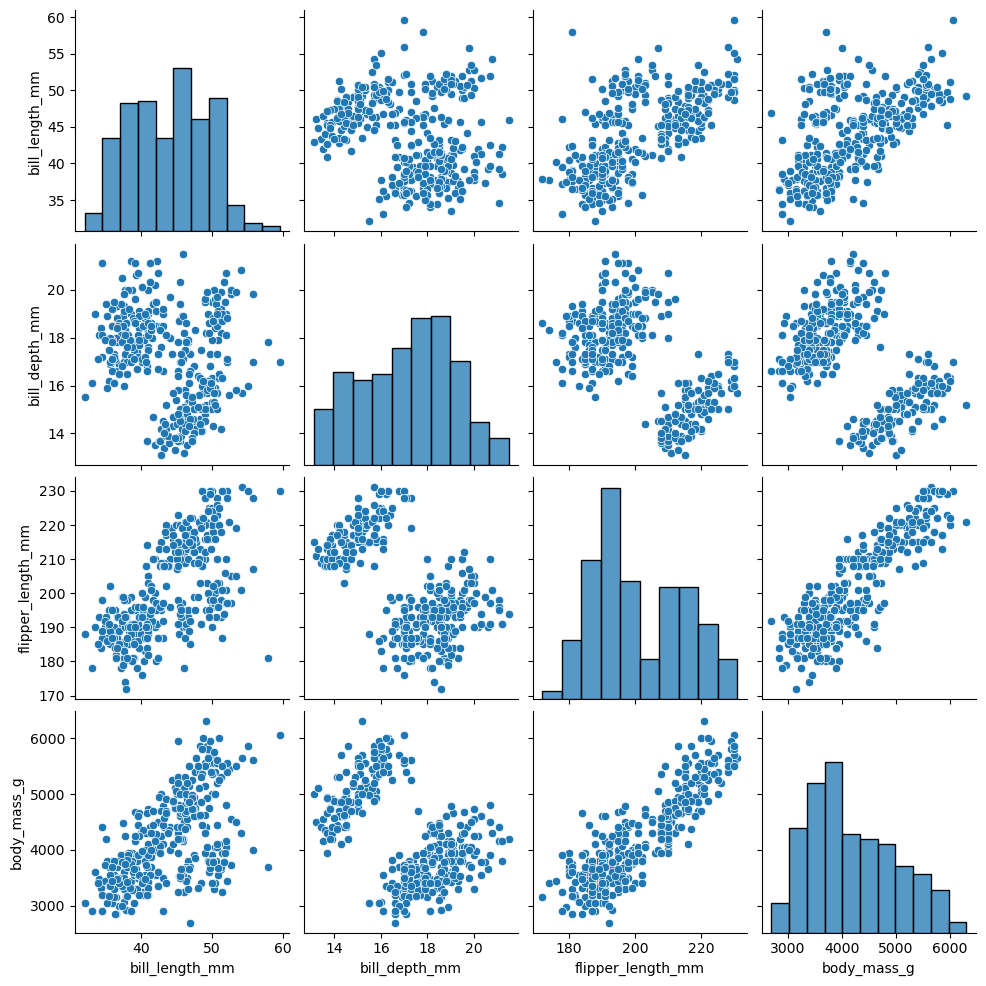

In [8]:
# seu código aqui
sns.pairplot(penguins_tratado)

**Sim já é possivel identificar possíveis grupamentos em sua maioria são 2 grupamentos com algumas categorias demonstrando 3 grupamentos**

# 3 - Realize a padronização dos dados e visualize os dados.

In [9]:
# seu código aqui
# Criando uma copia da base
penguins_padronizado = penguins_tratado.copy()

In [10]:
#Padronizando os dados
colunas_padronizar =['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']

#Inicializando o StandardScaler
scaler = StandardScaler()

#Ajustando e transformando
penguins_padronizado[colunas_padronizar] = scaler.fit_transform(penguins_tratado[colunas_padronizar])

In [11]:
#Visualizando os dados
penguins_padronizado

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
4,-1.324737,1.089724,-0.563715,-0.938776
5,-0.847812,1.748985,-0.777373,-0.689020
...,...,...,...,...
338,0.601305,-1.750171,0.931890,0.903175
340,0.527932,-1.445897,1.003109,0.809516
341,1.188289,-0.735923,1.501644,1.933419
342,0.234440,-1.192335,0.789451,1.246590


# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [12]:
# seu código aqui
#aplicando o k-means
kmeans_penguins = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_penguins.fit(penguins_padronizado)

C:\Users\Supervisor\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

In [13]:
# seu código aqui
# Centroides
centroides = kmeans_penguins.cluster_centers_
centroides

array([[ 0.66097295,  0.8169259 , -0.28620559, -0.37431308],
       [ 0.65722922, -1.09998045,  1.15886506,  1.0917612 ],
       [-1.04805941,  0.48655336, -0.89121603, -0.77061658]])

In [14]:
# Revertendo a padronização
centroides_padronizados = kmeans_penguins.cluster_centers_ # centroides já padronizados

#invertendo a padronização para saber os valores dos centroides originais
centroides_originais = scaler.inverse_transform(centroides_padronizados)
centroides_originais

array([[  47.52528736,   18.76206897,  196.89655172, 3902.01149425],
       [  47.50487805,   14.98211382,  217.18699187, 5076.01626016],
       [  38.20833333,   18.11060606,  188.40151515, 3584.65909091]])

In [15]:
#Criando as labels
labels = kmeans_penguins.labels_
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

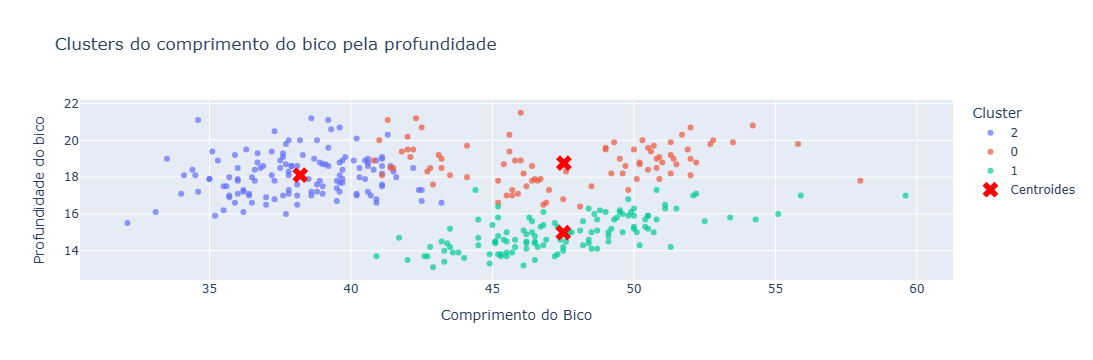

In [16]:
#Criando a matriz de dispersão 1
df_clusters = pd.DataFrame({
    'comprimento_bico': penguins_tratado['flipper_length_mm'],
    'profundidade_bico': penguins_tratado['bill_depth_mm'],
    'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='comprimento_bico', y='profundidade_bico', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters do comprimento do bico pela profundidade')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Comprimento do Bico', yaxis_title='Profundidade do bico',
                  legend_title='Cluster')
fig.show()

In [17]:
# Criando a matriz de dispersão 2
# Selecionando variáveis do clustering
df_clusters2 = pd.DataFrame({
    'comprimento_barbatana': penguins_tratado['bill_length_mm'],
    'massa_corporal': penguins_tratado['body_mass_g'],
    'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='comprimento_barbatana', y='massa_corporal', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters do comprimento do bico pela profundidade')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Comprimento do Barbatana', yaxis_title='Massa C',
                  legend_title='Cluster')
fig.show()

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

1. **Setor Financeiro e Seguros: Ajuda a identificar transações fraudulentas e agrupar clientes por nivel de risco**
2. **Tecnologia e Internet: Agrupando usuários com padrões semelhantes de acesso para recomendações de sites e afins e a classificação de emails em spam e não spam**
3. **Análise de Redes Sociais e tráfego: identifica grupos de interesse dentro de uma rede social baseado em interações, e classificar tipos de tráfego de internet(navegação/Streaming/Download)**